In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Optional prettier plots
import seaborn as sns
sns.set(style="whitegrid")

RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Advanced Machine Learning/car details v4.csv")

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (2059, 20)


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

None

In [ ]:
import re

# Drop duplicates
df = df.drop_duplicates()

# Convert year → car age
# Check if 'Year' column exists before processing it
if "Year" in df.columns:
    current_year = df["Year"].max()
    df["car_age"] = current_year - df["Year"]
    df = df.drop(columns=["Year"])

# ---- CLEAN STRING NUMERIC COLUMNS ----

def extract_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # Use regex to find the first sequence of digits, possibly with a decimal point
    match = re.search(r'^\d+\.?\d*', s)
    if match:
        return float(match.group(0))
    return np.nan # If no number found, return NaN

for col in ["Kilometer", "Engine", "Max Power"]:
    df[col] = df[col].apply(extract_number)

# Torque column is messy → extract first number
def extract_torque(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "")
    # Use regex to find the first sequence of digits, possibly with a decimal point
    match = re.search(r'^\d+\.?\d*', s)
    if match:
        return float(match.group(0))
    return np.nan # If no number found, return NaN

df["Max Torque"] = df["Max Torque"].apply(extract_torque)

# Drop Model (high-cardinality text, hard to explain)
df = df.drop(columns=["Model"])

print("\nMissing values after cleaning:")
display(df.isna().sum())


Missing values after cleaning:


,0
Make,0
Price,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0
Seller Type,0
Engine,80


In [ ]:
TARGET = "Price"

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['Kilometer', 'Engine', 'Max Power', 'Max Torque', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'car_age']
Categorical: ['Make', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Drivetrain']


In [ ]:
# Convert price columns to USD for plotting
df["Price_USD"] = df["Price"] * INR_TO_USD
df["Price_USD_log"] = np.log1p(df["Price_USD"])

In [ ]:
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

def format_usd_axis(ax):
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )

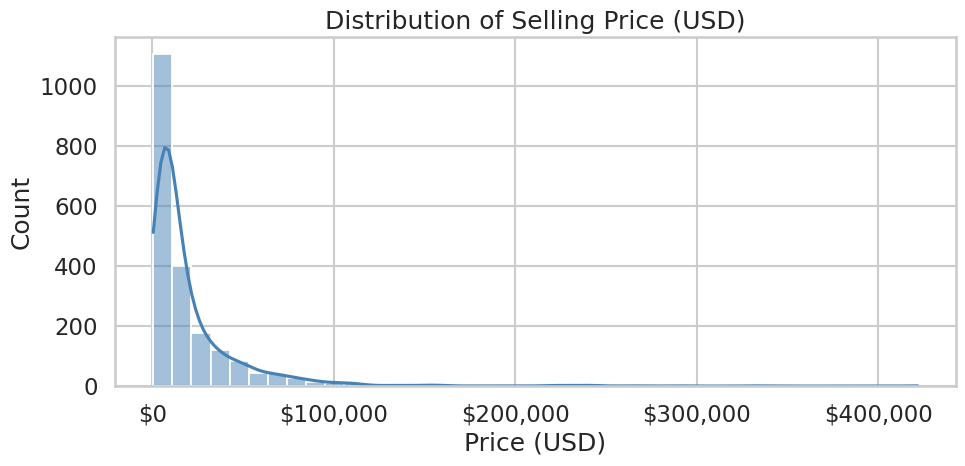

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price_USD"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Selling Price (USD)")
plt.xlabel("Price (USD)")
plt.ylabel("Count")

# Apply USD formatting to the X-axis ONLY
plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.tight_layout()
plt.show()

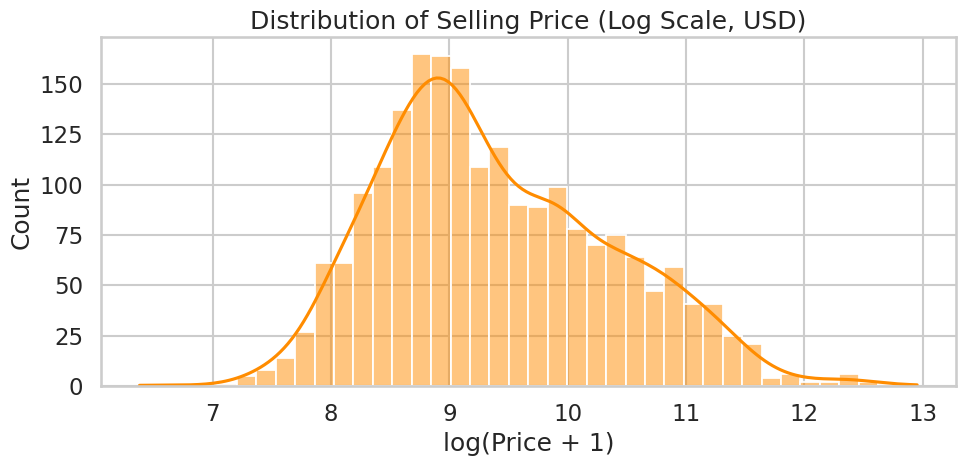

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price_USD_log"], bins=40, kde=True, color="darkorange")
plt.title("Distribution of Selling Price (Log Scale, USD)")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.ticker as mtick

def format_log_price_axis(ax):
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda y, _: f"${int(np.exp(y) - 1):,}")
    )

def format_thousands(ax, axis="x"):
    formatter = mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}k")
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)

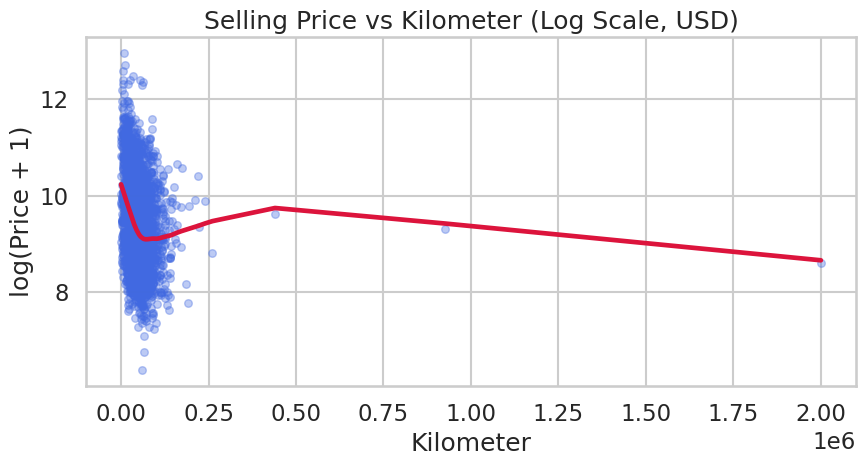

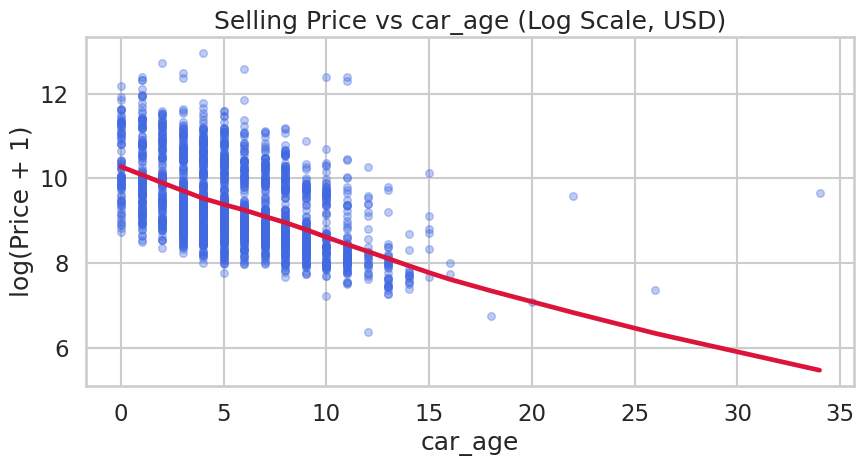

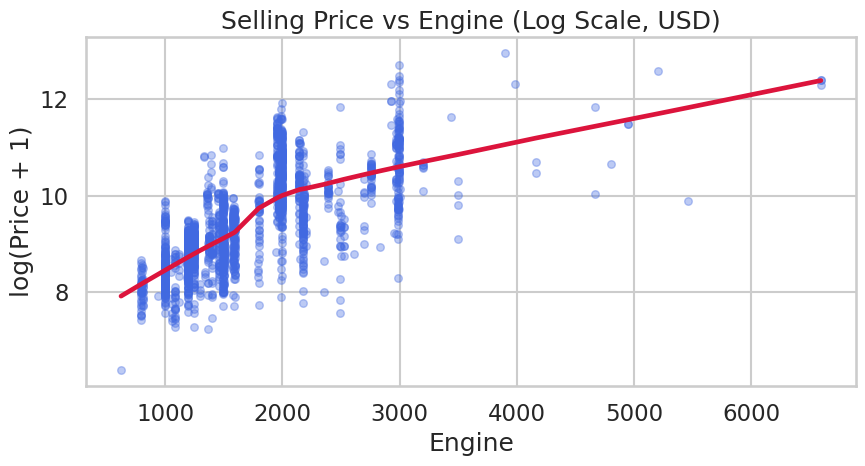

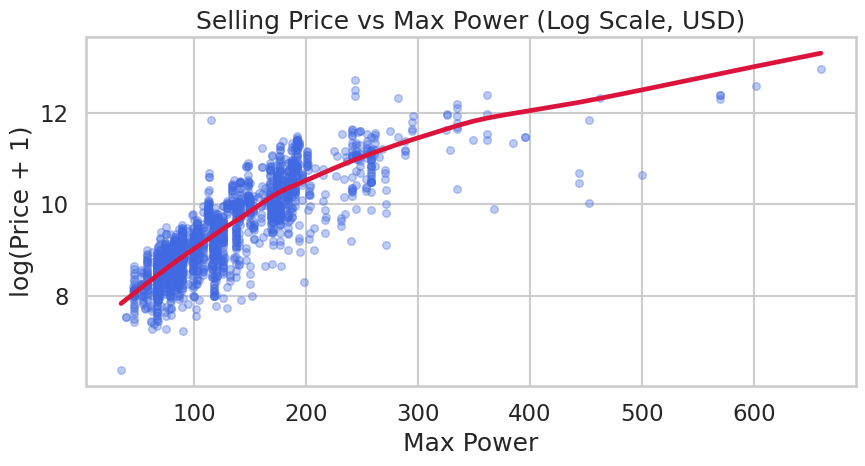

In [ ]:
num_cols = ["Kilometer", "car_age", "Engine", "Max Power"]

for col in num_cols:
    plt.figure(figsize=(9,5))
    sns.regplot(
        data=df,
        x=col,
        y="Price_USD_log",
        scatter_kws={"alpha":0.35, "s":30, "color":"royalblue"},
        line_kws={"color":"crimson"},
        lowess=True
    )
    plt.title(f"Selling Price vs {col} (Log Scale, USD)")
    plt.xlabel(col)
    plt.ylabel("log(Price + 1)")
    plt.tight_layout()
    plt.show()

In [ ]:
def top_k_boxplot_usd(df, cat_col, k=8):
    top_cats = df[cat_col].value_counts().head(k).index
    d = df[df[cat_col].isin(top_cats)].copy()

    plt.figure(figsize=(11,5))
    sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")
    plt.title(f"Selling Price by {cat_col} (USD, Top {k})")
    plt.xlabel(cat_col)
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=25, ha="right")
    format_usd_axis(plt.gca())
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


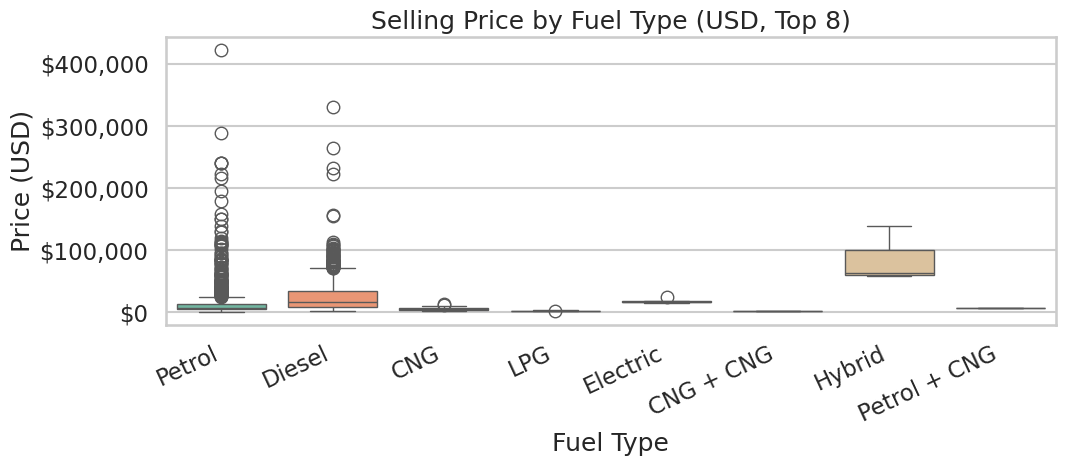

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


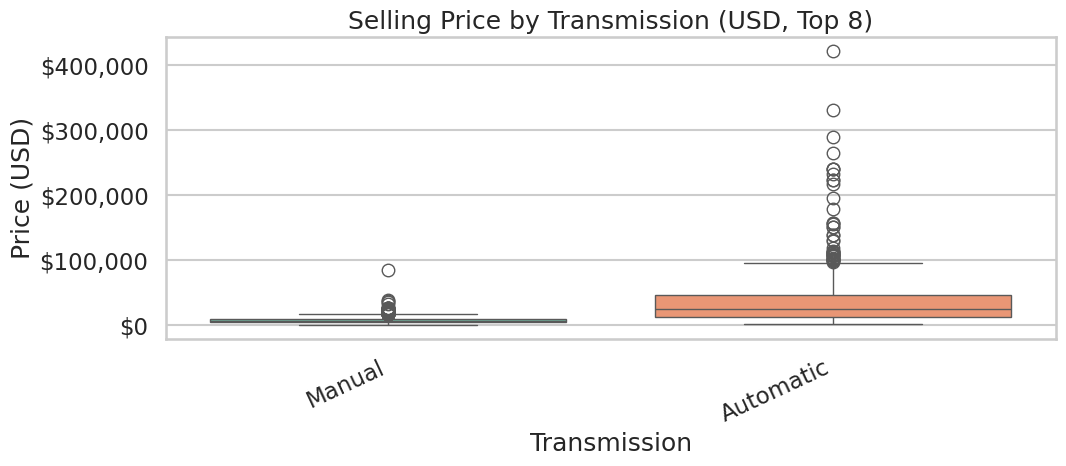

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


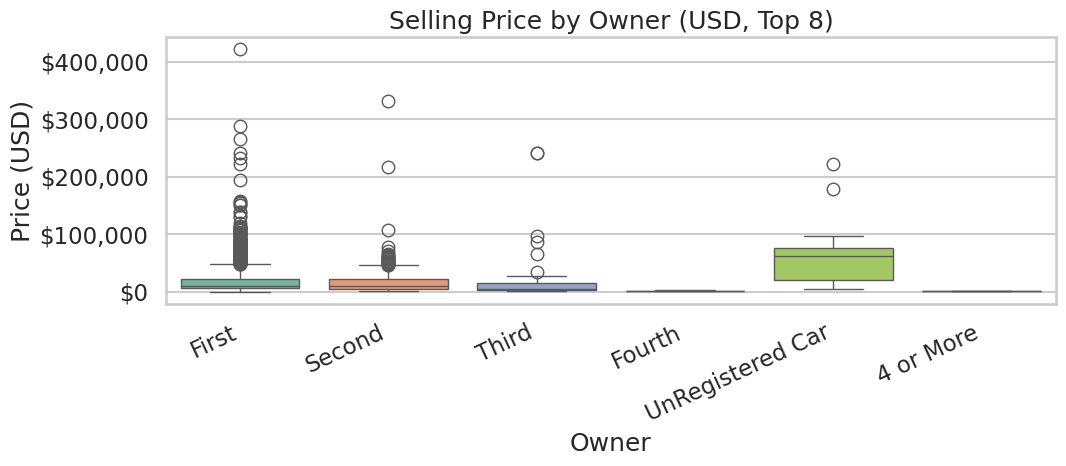

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


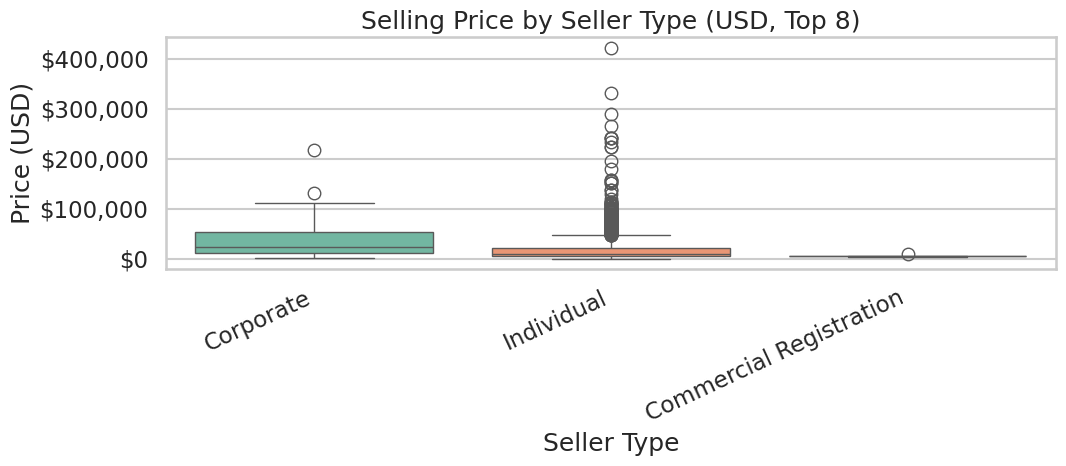

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


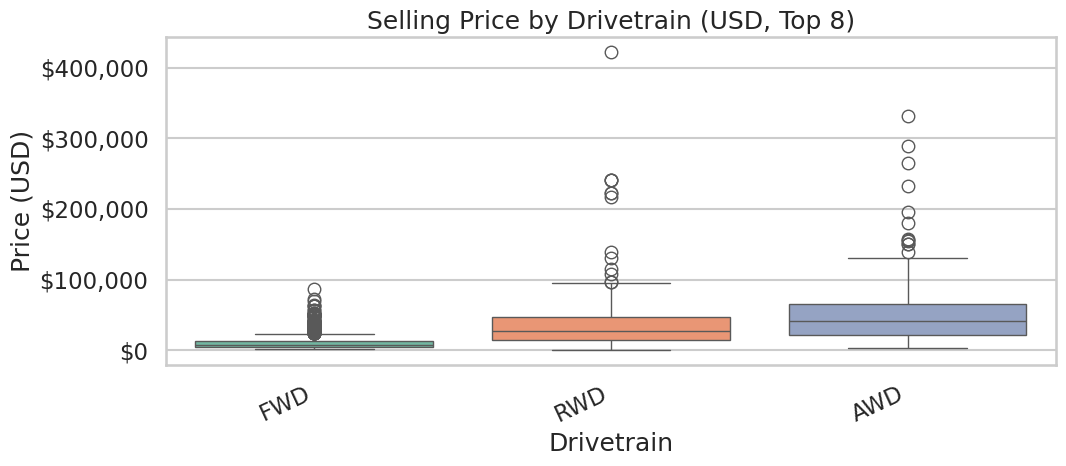

In [ ]:
for cat in ["Fuel Type", "Transmission", "Owner", "Seller Type", "Drivetrain"]:
    top_k_boxplot_usd(df, cat)

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


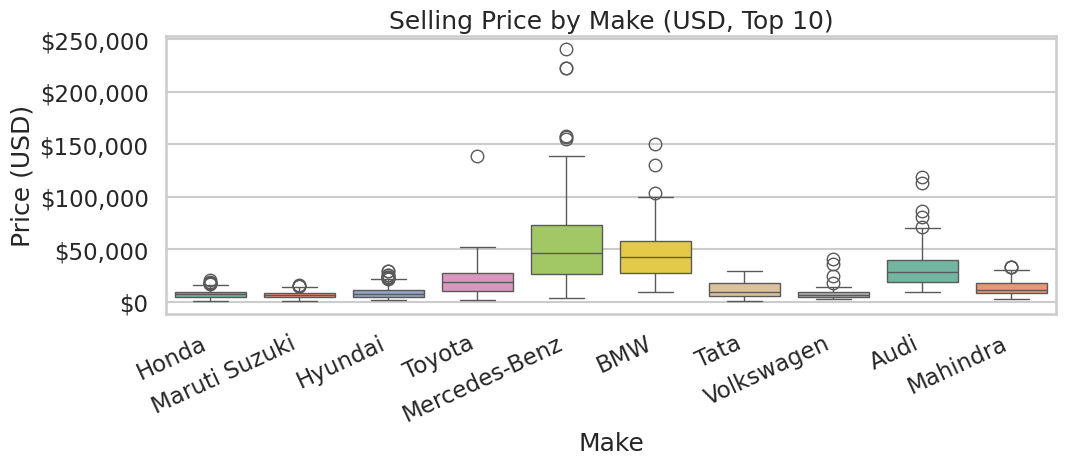

/tmp/ipython-input-3611449549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x=cat_col, y="Price_USD", palette="Set2")


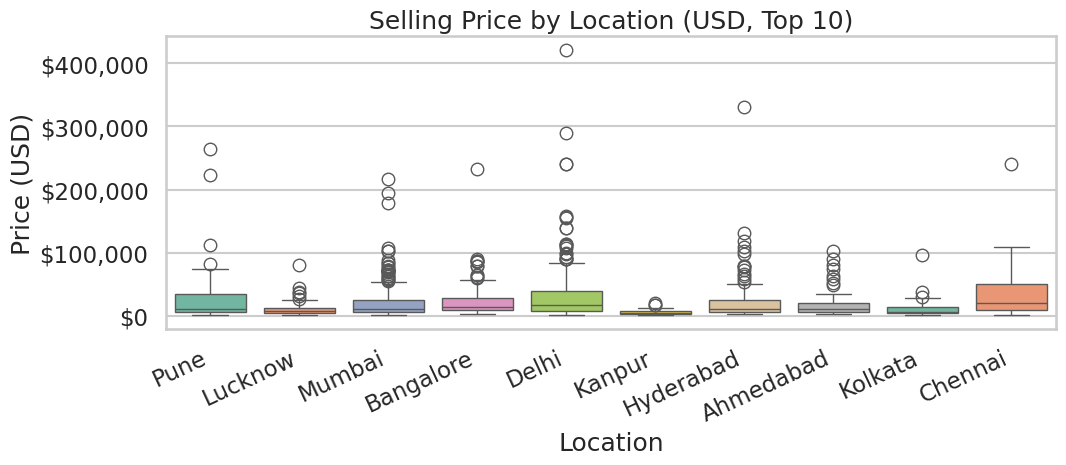

In [ ]:
top_k_boxplot_usd(df, "Make", k=10)
top_k_boxplot_usd(df, "Location", k=10)

/tmp/ipython-input-2565145010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


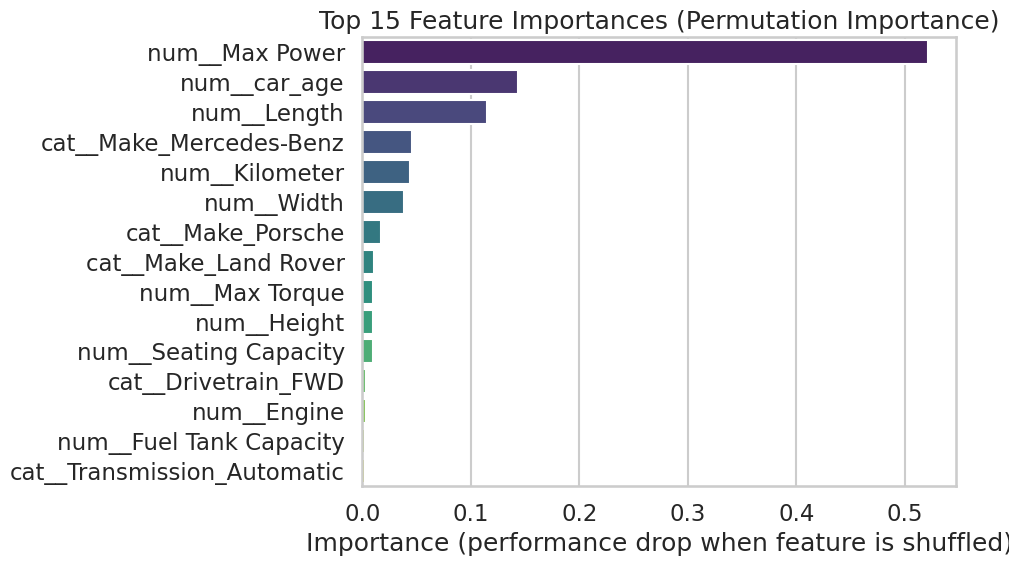

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 15 Feature Importances (Permutation Importance)")
plt.xlabel("Importance (performance drop when feature is shuffled)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [ ]:
baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

#Baseline evaluation (USD)

INR_TO_USD = 1 / 83  # exchange rate

y_pred = baseline_model.predict(X_test)

mae_inr = mean_absolute_error(y_test, y_pred)
rmse_inr = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

mae_usd = mae_inr * INR_TO_USD
rmse_usd = rmse_inr * INR_TO_USD

print("Baseline Model Performance (USD)")
print(f"MAE:  ${mae_usd:,.0f}")
print(f"RMSE: ${rmse_usd:,.0f}")
print(f"R²:   {r2:.3f}")

Baseline Model Performance (USD)
MAE:  $3,525
RMSE: $13,588
R²:   0.818


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_depth=8,
        learning_rate=0.05,
        max_iter=400,
        random_state=RANDOM_STATE
    ),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results.append({
        "Model": name,
        "MAE (USD)": mean_absolute_error(y_test, preds) * INR_TO_USD,
        "RMSE (USD)": mean_squared_error(y_test, preds) ** 0.5 * INR_TO_USD,
        "R²": r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values("MAE (USD)")
results_df

,Model,MAE (USD),RMSE (USD),R²
0,Random Forest,3524.951259,13587.806327,0.817942
1,Gradient Boosting,3692.187149,10286.537089,0.895661
2,Hist Gradient Boosting,3829.468936,14838.315533,0.782890
3,ElasticNet,8670.792262,17890.262620,0.684395


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.8, 1.0]
}

gbr_tuned = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

gbr_tuned.fit(X_train, y_train)

best_model = gbr_tuned.best_estimator_

In [ ]:
final_preds = best_model.predict(X_test)

final_results = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "MAE (USD)": mean_absolute_error(y_test, final_preds) * INR_TO_USD,
    "RMSE (USD)": (mean_squared_error(y_test, final_preds) ** 0.5) * INR_TO_USD,
    "R²": r2_score(y_test, final_preds)
}])

final_results

,Model,MAE (USD),RMSE (USD),R²
0,Tuned Gradient Boosting,3051.13603,10995.318958,0.880786
